Raw CSVs
      │
      ▼
Clean Customers
Clean Orders
Clean Order Items
Clean Payments
Clean Reviews
Clean Products
Clean Sellers
Clean Geolocation
Clean Translation
      │
      ▼
Validate each cleaned table
      │
      ▼
Save cleaned CSVs
      │
      ▼
Phase 3: Merge cleaned datasets
      │
      ▼
Feature Engineering

Section 1 – Project Objective (Markdown)
# Data Cleaning

## Objective

The purpose of this notebook is to clean all datasets before merging them for feature engineering and exploratory data analysis.

The cleaning process includes:

- Handling missing values
- Removing duplicate records
- Correcting data types
- Detecting invalid values
- Detecting and treating outliers
- Validating cleaned datasets
- Exporting cleaned datasets for the next phase

Section 2 – Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",100)

plt.style.use("ggplot")

Section 3 – Load Raw Datasets

In [2]:
customers = pd.read_csv("../dataset/raw/olist_customers_dataset.csv")

orders = pd.read_csv("../dataset/raw/olist_orders_dataset.csv")

order_items = pd.read_csv("../dataset/raw/olist_order_items_dataset.csv")

payments = pd.read_csv("../dataset/raw/olist_order_payments_dataset.csv")

reviews = pd.read_csv("../dataset/raw/olist_order_reviews_dataset.csv")

products = pd.read_csv("../dataset/raw/olist_products_dataset.csv")

sellers = pd.read_csv("../dataset/raw/olist_sellers_dataset.csv")

geolocation = pd.read_csv("../dataset/raw/olist_geolocation_dataset.csv")

translation = pd.read_csv("../dataset/raw/product_category_name_translation.csv")

Section 4 – Reusable Cleaning Functions

We'll create a small toolkit that we'll reuse throughout the notebook.

In [3]:
def dataset_summary(df, name):
    """
    Display basic information about a dataset.
    """

    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

    print("\nFirst Five Rows")
    display(df.head())

    print("\nDataset Information")
    df.info()

Function 2 – Missing Value Summary
Purpose

Generate a clean summary table of missing values.

In [4]:
def missing_summary(df):
    """
    Return missing value summary.
    """

    missing = df.isnull().sum()

    percentage = (
        missing / len(df)
    ) * 100

    summary = pd.DataFrame({
        "Missing Count": missing,
        "Missing Percentage": percentage.round(2)
    })

    summary = summary[
        summary["Missing Count"] > 0
    ]

    return summary.sort_values(
        by="Missing Percentage",
        ascending=False
    )

Function 3 – Duplicate Summary

In [5]:
def duplicate_summary(df):
    """
    Return duplicate record information.
    """

    duplicates = df.duplicated().sum()

    print(f"Duplicate Rows : {duplicates}")

    return duplicates

Function 4 – Remove Duplicates

In [6]:
def remove_duplicates(df):
    """
    Remove duplicate rows.
    """

    before = len(df)

    df = df.drop_duplicates()

    after = len(df)

    print(f"Rows Before : {before}")
    print(f"Rows After  : {after}")
    print(f"Removed     : {before-after}")

    return df

Function 5 – IQR Outlier Detection

We'll use the IQR method because it's simple, explainable, and widely accepted.

In [7]:
def detect_outliers_iqr(df, column):
    """
    Detect outliers using IQR.
    """

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return outliers

Function 6 – Box Plot

In [8]:
def plot_boxplot(df, column):
    """
    Display box plot.
    """

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(column)

    plt.show()

Function 7 – Distribution Plot

In [9]:
def plot_distribution(df, column):
    """
    Display distribution.
    """

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[column],
        kde=True
    )

    plt.title(column)

    plt.show()

Function 8 – Before vs After Comparison

This will be useful after every cleaning step.

In [10]:
def compare_shape(before_df, after_df):
    """
    Compare dataset dimensions before and after cleaning.
    """

    comparison = pd.DataFrame({
        "Stage": ["Before", "After"],
        "Rows": [
            before_df.shape[0],
            after_df.shape[0]
        ],
        "Columns": [
            before_df.shape[1],
            after_df.shape[1]
        ]
    })

    return comparison

Why These Functions?

Instead of repeating code like this nine times:

customers.isnull().sum()

orders.isnull().sum()

products.isnull().sum()

payments.isnull().sum()

...

you'll simply write:

missing_summary(customers)

missing_summary(products)

missing_summary(payments)

The notebook becomes much shorter, easier to maintain, and more professional.

Section 5 – Clean Translation Dataset

This is the smallest dataset and a good place to establish our cleaning workflow.

In [11]:
# Step 1 – Dataset Summary

dataset_summary(
    translation,
    "Product Category Translation"
)

PRODUCT CATEGORY TRANSLATION
Rows    : 71
Columns : 2

First Five Rows


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [12]:
# Step 2 – Missing Values

missing_summary(translation)

,Missing Count,Missing Percentage


In [13]:
# Step 3 – Duplicate Records

duplicate_summary(translation)


Duplicate Rows : 0


np.int64(0)

If duplicates exist: Run this code

translation_before = translation.copy()

translation = remove_duplicates(translation)

compare_shape(
    translation_before,
    translation
)

In [14]:
# Step 4 – Data Type Validation

translation.dtypes

product_category_name            str
product_category_name_english    str
dtype: object

Step 5 – Invalid Data Check

A lookup table should not contain blank strings.

In [15]:
translation[
    (translation["product_category_name"].str.strip() == "") |
    (translation["product_category_name_english"].str.strip() == "")
]

,product_category_name,product_category_name_english


Step 6 – Check Unique Categories

In [16]:
translation["product_category_name"].nunique()

71

In [17]:
translation["product_category_name_english"].nunique()

71

Step 7 – Check for Duplicate Keys

In [18]:
translation[
    translation.duplicated(
        subset="product_category_name",
        keep=False
    )
]

,product_category_name,product_category_name_english


Step 8 – Validation Summary

In [19]:
translation_validation = {
    "Rows": len(translation),
    "Columns": translation.shape[1],
    "Missing Values": translation.isnull().sum().sum(),
    "Duplicate Rows": translation.duplicated().sum(),
    "Unique Portuguese Categories": translation["product_category_name"].nunique(),
    "Unique English Categories": translation["product_category_name_english"].nunique()
}

pd.DataFrame(
    translation_validation.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows,71
1,Columns,2
2,Missing Values,0
3,Duplicate Rows,0
4,Unique Portuguese Categories,71
5,Unique English Categories,71


Step 9 – Export the Cleaned Dataset

In [20]:
translation.to_csv(
    "../dataset/cleaned/translation_cleaned.csv",
    index=False
)

Section 6 – Clean Products Dataset

In [21]:
# Step 1 – Dataset Summary

dataset_summary(products, "Products Dataset")

PRODUCTS DATASET
Rows    : 32951
Columns : 9

First Five Rows


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [22]:
# Step 2 – Missing Value Analysis

missing_summary(products)

,Missing Count,Missing Percentage
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


Step 3 – Understand the Missing Values

Before filling or dropping anything, inspect the affected rows.

In [23]:
products[
    products.isnull().any(axis=1)
].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


Step 4 – Duplicate Records

In [24]:
duplicate_summary(products)

Duplicate Rows : 0


np.int64(0)

If duplicates exist: Run this command

products_before = products.copy()

products = remove_duplicates(products)

compare_shape(products_before, products)

In [25]:
# Step 5 – Data Type Validation

products.dtypes

product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Step 6 – Validate Product Categories

Now use the cleaned translation table.

In [26]:
valid_categories = set(
    translation["product_category_name"]
)

invalid_categories = products[
    ~products["product_category_name"].isin(valid_categories)
]

invalid_categories

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


Step 7 – Detect Invalid Numeric Values

Product dimensions and weight should not be negative or zero.

In [27]:
numeric_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for column in numeric_columns:

    invalid = products[
        products[column] <= 0
    ]

    print(column)
    print("Invalid Records :", len(invalid))

product_weight_g
Invalid Records : 4
product_length_cm
Invalid Records : 0
product_height_cm
Invalid Records : 0
product_width_cm
Invalid Records : 0


Step 8 – Handle Missing Values

Different columns require different strategies.

In [28]:
products["product_category_name"] = (
    products["product_category_name"]
    .fillna("Unknown")
)

In [29]:
"""
Numerical Columns

Median is more robust than the mean because these measurements can contain extreme values:


columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_photos_qty",
    "product_name_lenght",
    "product_description_lenght"
]

for column in columns:

    products[column] = (
        products[column]
        .fillna(
            products[column].median()
        )
    )

"""

'\nNumerical Columns\n\nMedian is more robust than the mean because these measurements can contain extreme values:\n\n\ncolumns = [\n    "product_weight_g",\n    "product_length_cm",\n    "product_height_cm",\n    "product_width_cm",\n    "product_photos_qty",\n    "product_name_lenght",\n    "product_description_lenght"\n]\n\nfor column in columns:\n\n    products[column] = (\n        products[column]\n        .fillna(\n            products[column].median()\n        )\n    )\n\n'

In [30]:
# Step 9 – Verify Missing Values Again

missing_summary(products)

,Missing Count,Missing Percentage
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


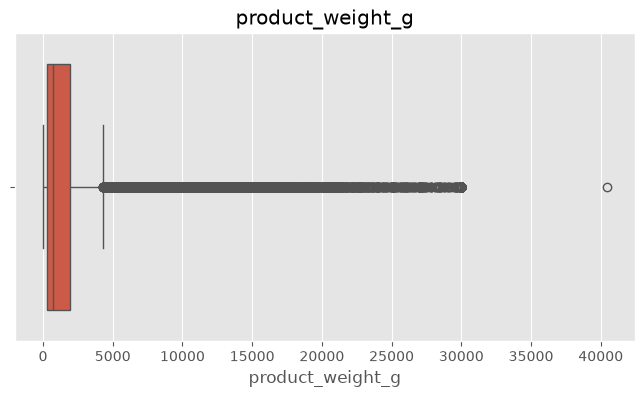

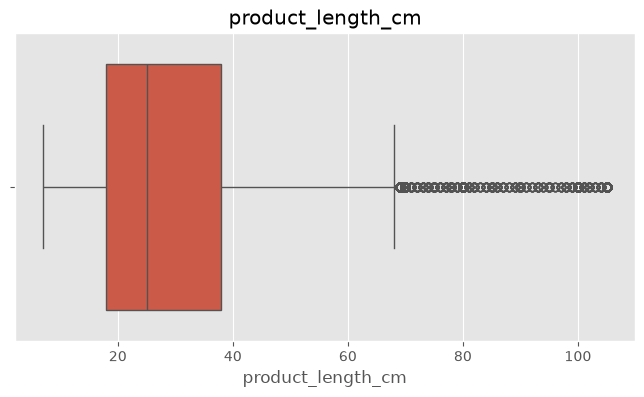

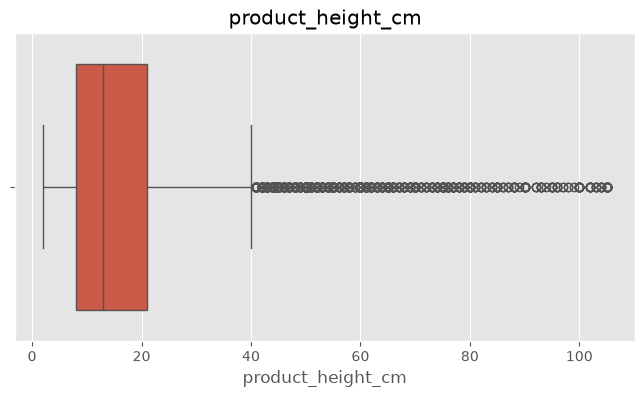

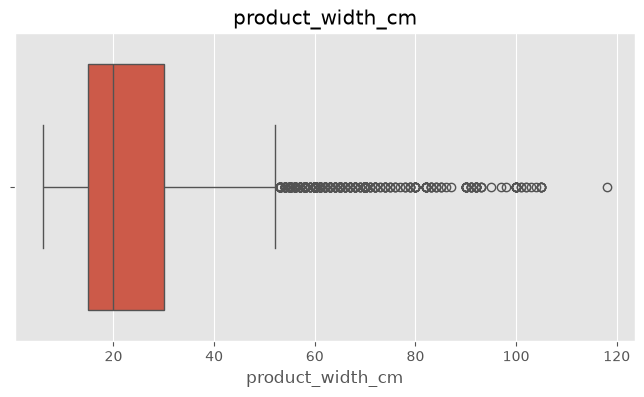

In [31]:
# Step 10 – Outlier Detection

# Visualize each numerical column before deciding whether to treat outliers.


numeric_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for column in numeric_columns:

    plot_boxplot(products, column)

In [32]:
# Step 11 – Count Outliers

for column in numeric_columns:

    outliers = detect_outliers_iqr(
        products,
        column
    )

    print(f"{column}: {len(outliers)} outliers")

product_weight_g: 4551 outliers
product_length_cm: 1380 outliers
product_height_cm: 1892 outliers
product_width_cm: 912 outliers


In [33]:
# Step 13 – Final Validation

products_validation = {
    "Rows": len(products),
    "Columns": products.shape[1],
    "Missing Values": products.isnull().sum().sum(),
    "Duplicate Rows": products.duplicated().sum()
}

pd.DataFrame(
    products_validation.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows,32951
1,Columns,9
2,Missing Values,1838
3,Duplicate Rows,0


In [34]:
# Step 14 – Export

products.to_csv(
    "../dataset/cleaned/products_cleaned.csv",
    index=False
)

Section 7 – Clean Customers Dataset

In [35]:
# Step 1 – Dataset Summary

dataset_summary(customers, "Customers Dataset")

CUSTOMERS DATASET
Rows    : 99441
Columns : 5

First Five Rows


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [36]:
# Step 2 – Missing Value Analysis

missing_summary(customers)

,Missing Count,Missing Percentage


In [37]:
# Step 3 – Duplicate Record Analysis

duplicate_summary(customers)

Duplicate Rows : 0


np.int64(0)

In [38]:
"""
If duplicates exist:

customers_before = customers.copy()

customers = remove_duplicates(customers)

compare_shape(customers_before, customers)
"""

'\nIf duplicates exist:\n\ncustomers_before = customers.copy()\n\ncustomers = remove_duplicates(customers)\n\ncompare_shape(customers_before, customers)\n'

In [39]:
# Step 4 – Check Primary Key (customer_id)

# customer_id should be unique because it is the primary key.


customers["customer_id"].duplicated().sum()

np.int64(0)

In [40]:
"""
If duplicates exist:

customers[
    customers["customer_id"].duplicated(keep=False)
]
"""

'\nIf duplicates exist:\n\ncustomers[\n    customers["customer_id"].duplicated(keep=False)\n]\n'

In [41]:
# Step 5 – Check customer_unique_id

# Unlike customer_id, customer_unique_id is expected to repeat.

Step 6 – Validate State Codes

Brazilian state codes should contain exactly 2 uppercase letters.

In [42]:
customers["customer_state"].unique()

<StringArray>
['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA', 'MS', 'CE',
 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB', 'TO', 'PI', 'AC', 'SE',
 'RR']
Length: 27, dtype: str

In [43]:
# Now check for invalid values.

invalid_states = customers[
    customers["customer_state"].str.len() != 2
]

invalid_states

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


Step 7 – Check Blank Strings

Missing values and blank strings are different.

In [44]:
for column in customers.select_dtypes(include="object").columns:

    blanks = customers[
        customers[column].str.strip() == ""
    ]

    print(column)
    print(len(blanks))

customer_id
0
customer_unique_id
0
customer_city
0
customer_state
0


/tmp/ipykernel_76854/1431045457.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in customers.select_dtypes(include="object").columns:


Step 8 – Validate ZIP Code Prefix

ZIP prefixes should be positive integers.

In [45]:
customers[
    customers["customer_zip_code_prefix"] <= 0
]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


Step 9 – Standardize Text Columns

To ensure consistency during analysis, normalize text fields.

In [46]:
customers["customer_city"] = (
    customers["customer_city"]
    .str.strip()
    .str.title()
)

customers["customer_state"] = (
    customers["customer_state"]
    .str.strip()
    .str.upper()
)

Step 10 – Final Validation

In [47]:
customers_validation = {
    "Rows": len(customers),
    "Columns": customers.shape[1],
    "Missing Values": customers.isnull().sum().sum(),
    "Duplicate Rows": customers.duplicated().sum(),
    "Unique customer_id": customers["customer_id"].nunique(),
    "Unique customer_unique_id": customers["customer_unique_id"].nunique()
}

pd.DataFrame(
    customers_validation.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows,99441
1,Columns,5
2,Missing Values,0
3,Duplicate Rows,0
4,Unique customer_id,99441
5,Unique customer_unique_id,96096


In [48]:
# Step 11 – Export

customers.to_csv(
    "../dataset/cleaned/customers_cleaned.csv",
    index=False
)

Section 8 – Clean Sellers Dataset
Objective

Validate and standardize seller information before merging with the Order Items dataset.

In [49]:
# Step 1 – Dataset Summary

dataset_summary(
    sellers,
    "Sellers Dataset"
)

SELLERS DATASET
Rows    : 3095
Columns : 4

First Five Rows


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


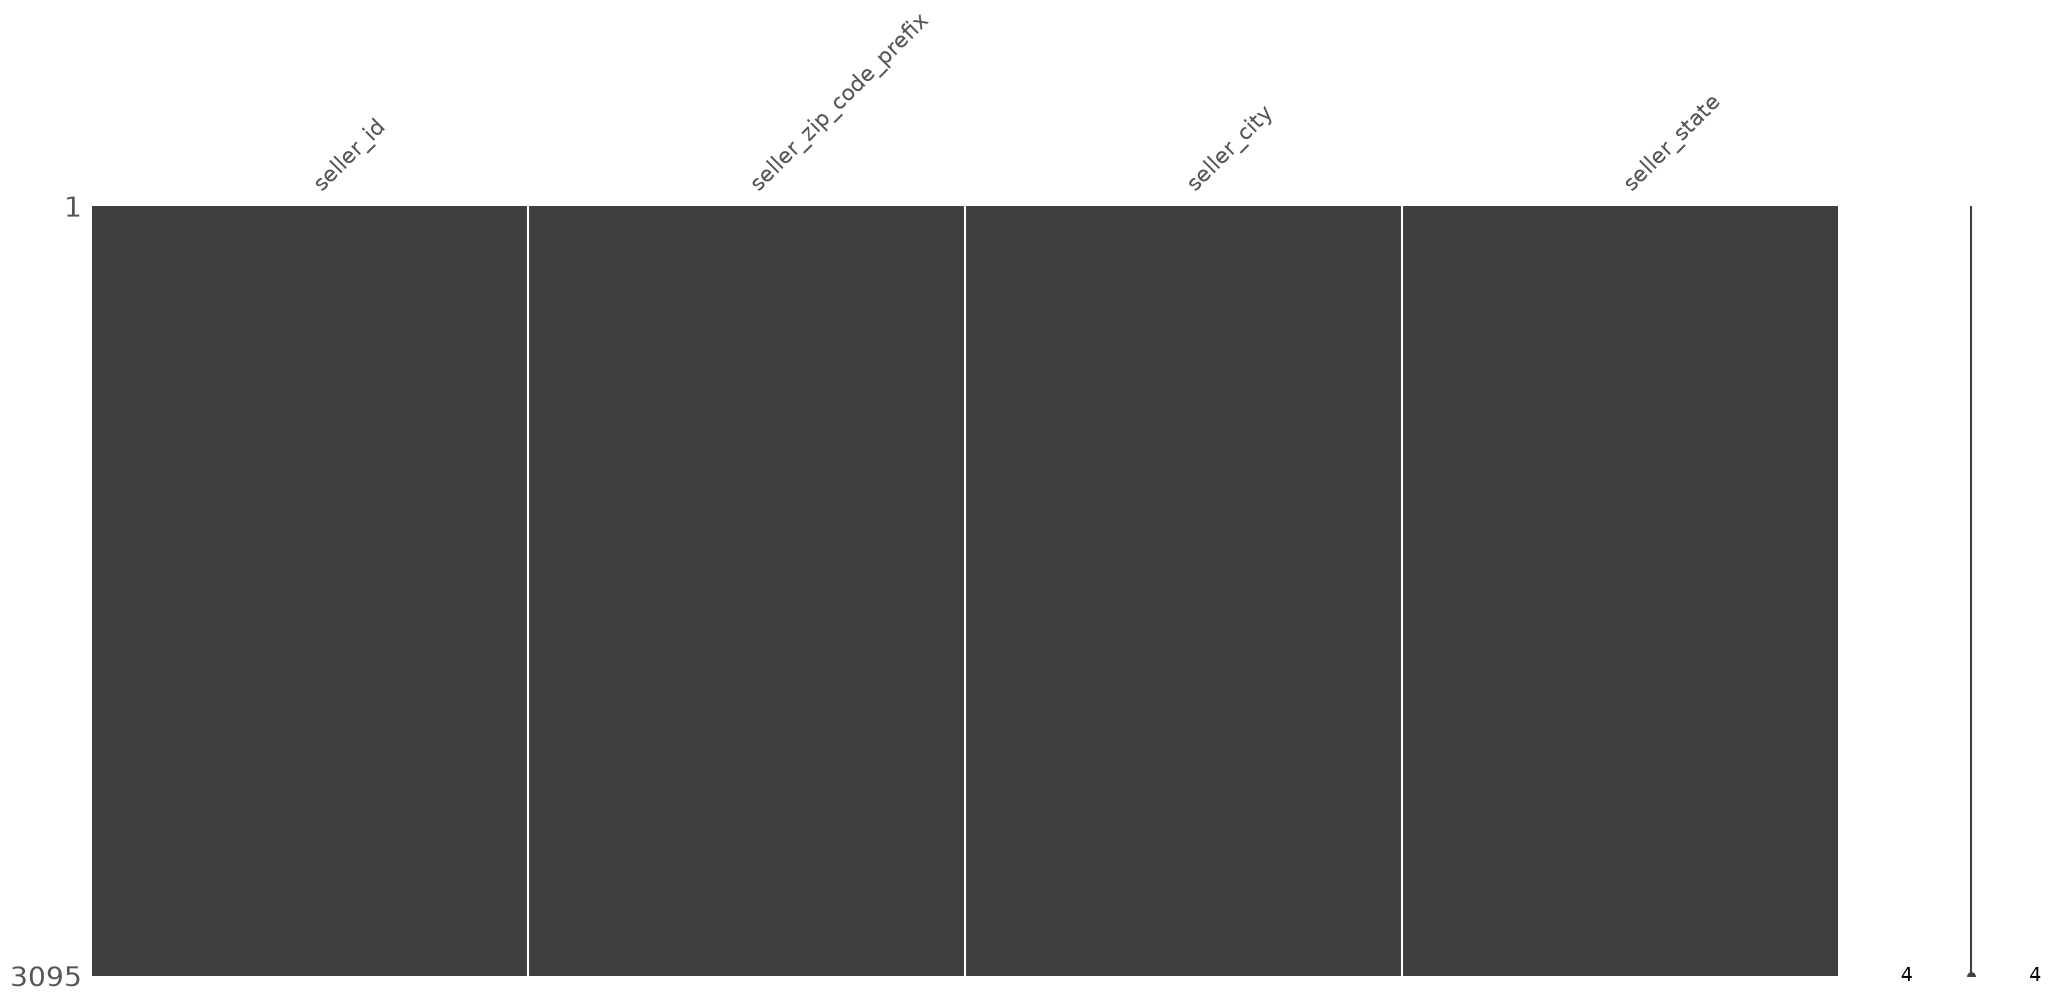

In [50]:
# Step 2 – Missing Value Analysis

missing_summary(sellers)

# Visualize the missing values.

msno.matrix(sellers)

plt.show()

In [51]:
# Step 3 – Duplicate Record Analysis

# Check complete duplicate rows.

duplicate_summary(sellers)

""" If duplicates exist:

sellers_before = sellers.copy()

sellers = remove_duplicates(sellers)

compare_shape(
    sellers_before,
    sellers
) """

Duplicate Rows : 0


' If duplicates exist:\n\nsellers_before = sellers.copy()\n\nsellers = remove_duplicates(sellers)\n\ncompare_shape(\n    sellers_before,\n    sellers\n) '

In [52]:
# Step 4 – Validate Primary Key (seller_id)

## Each seller should appear only once.

sellers["seller_id"].duplicated().sum()


""" If duplicates exist:

sellers[
    sellers["seller_id"].duplicated(
        keep=False
    )
] """

' If duplicates exist:\n\nsellers[\n    sellers["seller_id"].duplicated(\n        keep=False\n    )\n] '

In [53]:
# Step 5 – Validate ZIP Code Prefix

# ZIP code prefixes should be positive integers.

sellers[
    sellers["seller_zip_code_prefix"] <= 0
]

,seller_id,seller_zip_code_prefix,seller_city,seller_state


In [54]:
# Step 6 – Validate State Codes

# Brazilian state abbreviations should contain exactly two uppercase letters.

sellers["seller_state"].unique()



<StringArray>
['SP', 'RJ', 'PE', 'PR', 'GO', 'SC', 'BA', 'DF', 'RS', 'MG', 'RN', 'MT', 'CE',
 'PB', 'AC', 'ES', 'RO', 'PI', 'MS', 'SE', 'MA', 'AM', 'PA']
Length: 23, dtype: str

In [55]:
# Check for invalid values.

invalid_states = sellers[
    sellers["seller_state"].str.len() != 2
]

invalid_states

,seller_id,seller_zip_code_prefix,seller_city,seller_state


In [56]:
# Step 7 – Check Blank Strings

for column in sellers.select_dtypes(include="object").columns:

    blanks = sellers[
        sellers[column].str.strip() == ""
    ]

    print(column)
    print(len(blanks))

seller_id
0
seller_city
0
seller_state
0


/tmp/ipykernel_76854/2824851103.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in sellers.select_dtypes(include="object").columns:


In [57]:
# Step 8 – Standardize Text Columns

# Normalize city and state names for consistency.

sellers["seller_city"] = (
    sellers["seller_city"]
    .str.strip()
    .str.title()
)

sellers["seller_state"] = (
    sellers["seller_state"]
    .str.strip()
    .str.upper()
)

In [58]:
# Step 9 – Final Validation

sellers_validation = {
    "Rows": len(sellers),
    "Columns": sellers.shape[1],
    "Missing Values": sellers.isnull().sum().sum(),
    "Duplicate Rows": sellers.duplicated().sum(),
    "Unique seller_id": sellers["seller_id"].nunique()
}

pd.DataFrame(
    sellers_validation.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows,3095
1,Columns,4
2,Missing Values,0
3,Duplicate Rows,0
4,Unique seller_id,3095


In [59]:
# Step 10 – Export
sellers.to_csv(
    "../dataset/cleaned/sellers_cleaned.csv",
    index=False
)

Section 9 – Clean Orders Dataset

In [60]:
# Step 1 – Dataset Summary

dataset_summary(
    orders,
    "Orders Dataset"
)

ORDERS DATASET
Rows    : 99441
Columns : 8

First Five Rows


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Dataset Information


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


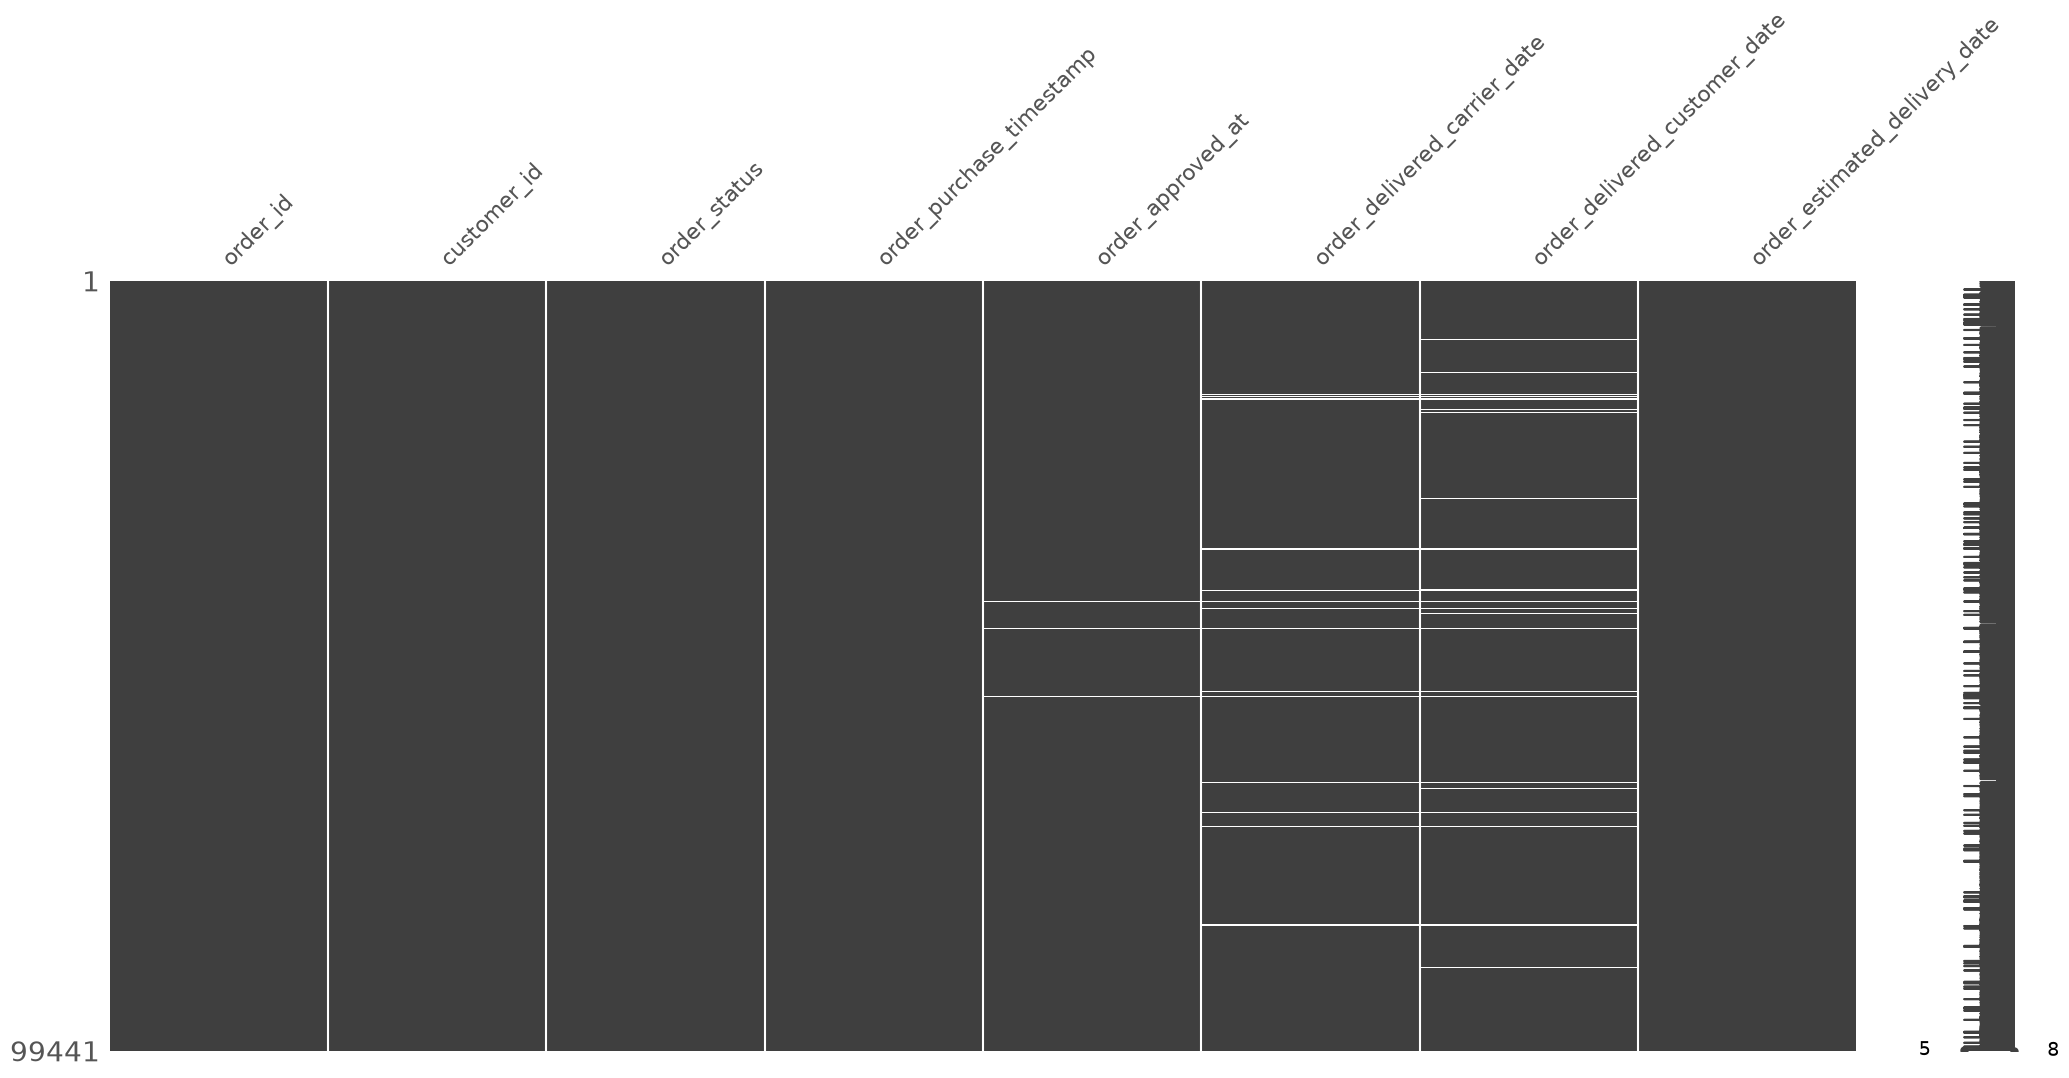

In [61]:
# Step 2 – Missing Value Analysis

missing_summary(orders)

# Visualize:

msno.matrix(orders)

plt.show()

In [62]:
# Step 3 – Duplicate Record Analysis

duplicate_summary(orders)

""" If duplicates exist:

orders_before = orders.copy()

orders = remove_duplicates(orders)

compare_shape(
    orders_before,
    orders
) """

Duplicate Rows : 0


' If duplicates exist:\n\norders_before = orders.copy()\n\norders = remove_duplicates(orders)\n\ncompare_shape(\n    orders_before,\n    orders\n) '

In [63]:
# Step 4 – Validate Primary Key

orders["order_id"].duplicated().sum()

np.int64(0)

In [64]:
# Step 5 – Validate Foreign Key (customer_id)

# Now check whether every order references a valid customer.

invalid_customer_orders = orders[
    ~orders["customer_id"].isin(
        customers["customer_id"]
    )
]

print("Invalid Customer References:", len(invalid_customer_orders))

Invalid Customer References: 0


In [65]:
# Step 6 – Convert Date Columns

# Convert all timestamp columns.

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

In [66]:
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [67]:
# Step 7 – Validate Order Status

# See all statuses.

orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [68]:
expected_status = {
    "created",
    "approved",
    "processing",
    "invoiced",
    "shipped",
    "delivered",
    "canceled",
    "unavailable"
}

invalid_status = orders[
    ~orders["order_status"].isin(expected_status)
]

invalid_status

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [69]:
# Step 8 – Validate Date Logic

# Purchase date should not occur after approval date.

orders[
    orders["order_purchase_timestamp"] >
    orders["order_approved_at"]
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [70]:
# Step 9 – Missing Date Validation

# Orders that are not delivered may legitimately have missing delivery dates.

# Let's quantify them.

orders.groupby("order_status")[
    "order_delivered_customer_date"
].apply(lambda x: x.isna().sum())

order_status
approved          2
canceled        619
created           5
delivered         8
invoiced        314
processing      301
shipped        1107
unavailable     609
Name: order_delivered_customer_date, dtype: int64

In [71]:
# Step 10 – Final Validation

orders_validation = {
    "Rows": len(orders),
    "Columns": orders.shape[1],
    "Missing Values": orders.isnull().sum().sum(),
    "Duplicate Rows": orders.duplicated().sum(),
    "Unique Orders": orders["order_id"].nunique(),
    "Unique Customers": orders["customer_id"].nunique()
}

pd.DataFrame(
    orders_validation.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows,99441
1,Columns,8
2,Missing Values,4908
3,Duplicate Rows,0
4,Unique Orders,99441
5,Unique Customers,99441


In [72]:
# Step 11 – Export

orders.to_csv(
    "../dataset/cleaned/orders_cleaned.csv",
    index=False
)

In [73]:
def validate_foreign_key(df, key_column, reference_df, reference_column):
    """
    Validate foreign key relationships between two DataFrames.
    """

    invalid_records = df[
        ~df[key_column].isin(reference_df[reference_column])
    ]

    print(f"Foreign Key: {key_column}")
    print(f"Invalid Records: {len(invalid_records)}")

    return invalid_records

Section 10 – Clean Order Items Dataset

In [74]:
# Step 1 – Dataset Summary

dataset_summary(
    order_items,
    "Order Items Dataset"
)

ORDER ITEMS DATASET
Rows    : 112650
Columns : 7

First Five Rows


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


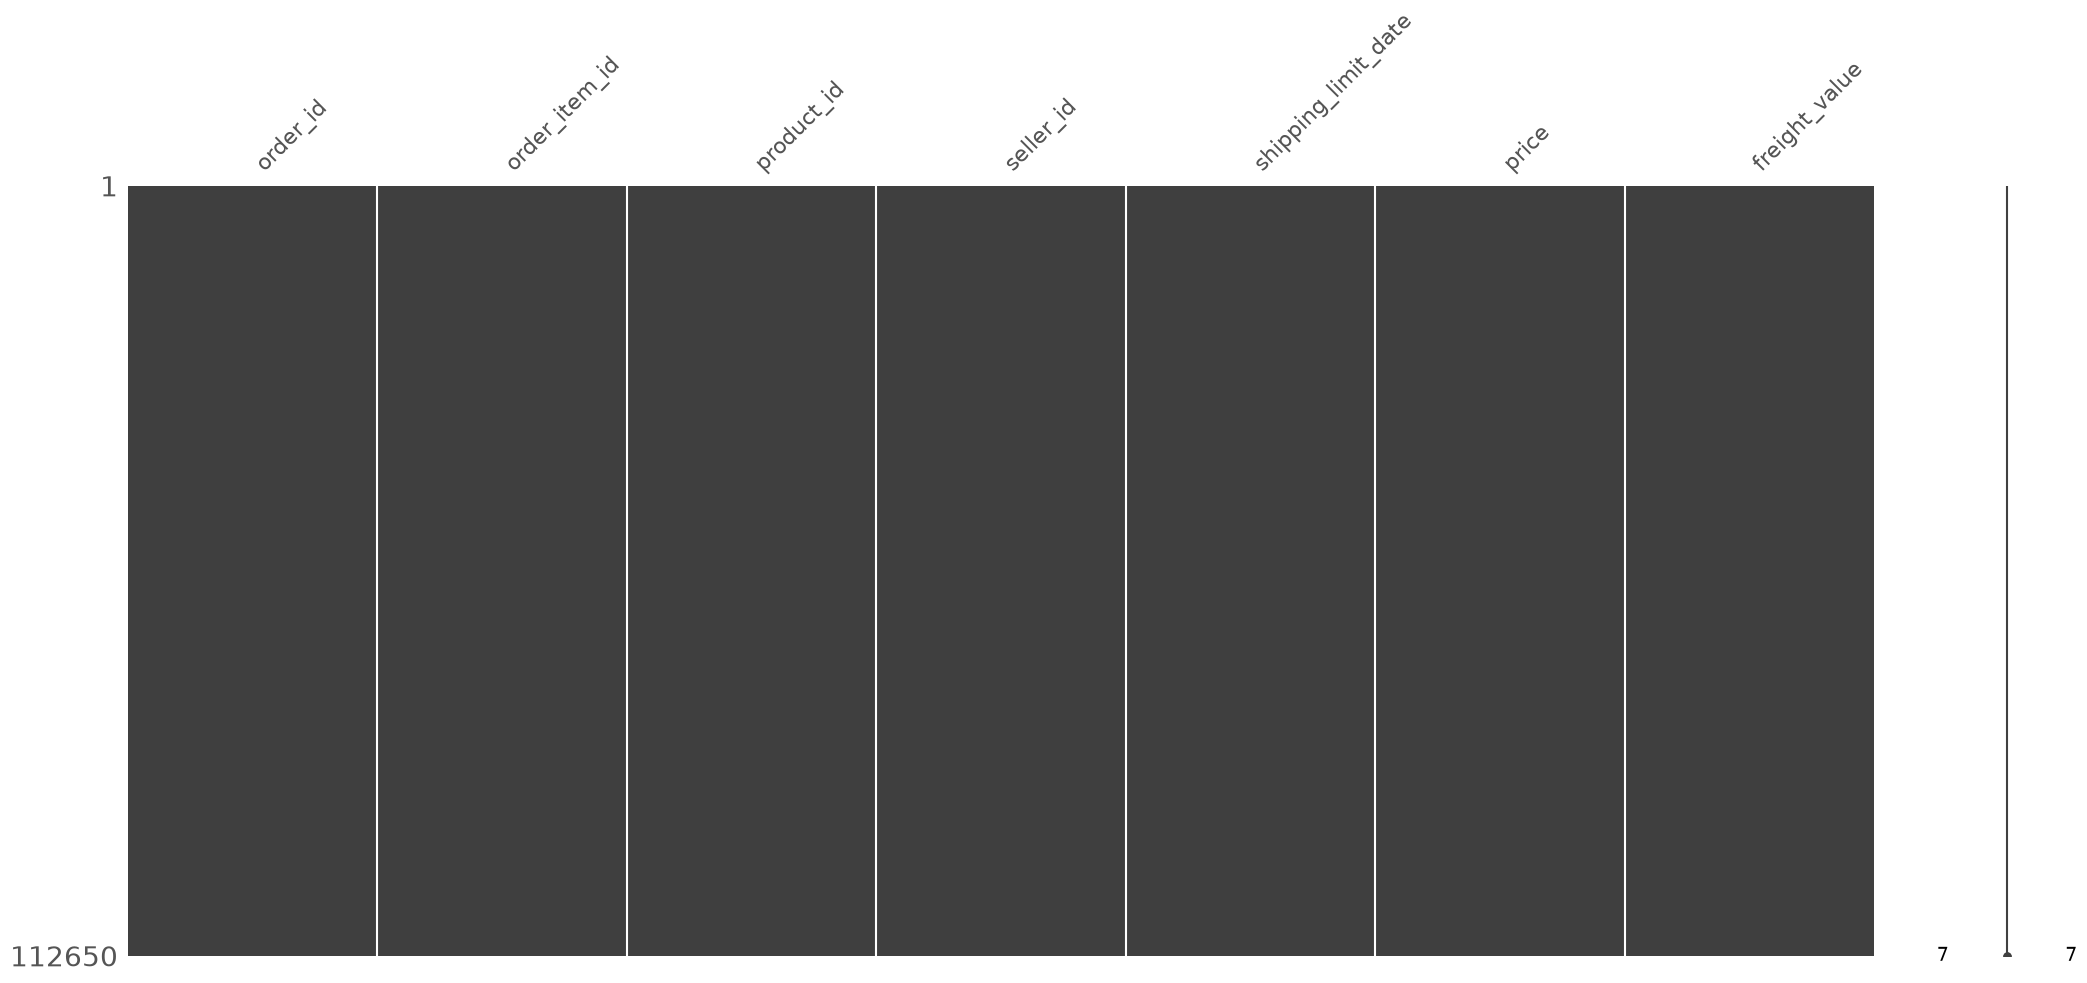

In [75]:
# Step 2 – Missing Value Analysis

missing_summary(order_items)

# Visualize:

msno.matrix(order_items)

plt.show()

In [76]:
# Step 3 – Duplicate Record Analysis

# Check complete duplicate rows.

duplicate_summary(order_items)

"""If duplicates exist:

order_items_before = order_items.copy()

order_items = remove_duplicates(order_items)

compare_shape(
    order_items_before,
    order_items
)"""

Duplicate Rows : 0


'If duplicates exist:\n\norder_items_before = order_items.copy()\n\norder_items = remove_duplicates(order_items)\n\ncompare_shape(\n    order_items_before,\n    order_items\n)'

In [77]:
# Step 4 – Validate Foreign Keys

# Validate Orders

invalid_orders = validate_foreign_key(
    order_items,
    "order_id",
    orders,
    "order_id"
)

Foreign Key: order_id
Invalid Records: 0


In [78]:
# Validate Products

invalid_products = validate_foreign_key(
    order_items,
    "product_id",
    products,
    "product_id"
)

Foreign Key: product_id
Invalid Records: 0


In [79]:
# Validate Sellers

invalid_sellers = validate_foreign_key(
    order_items,
    "seller_id",
    sellers,
    "seller_id"
)

Foreign Key: seller_id
Invalid Records: 0


In [80]:
# Step 5 – Convert Date Column

order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"],
    errors="coerce"
)

In [81]:
order_items["shipping_limit_date"].dtype

dtype('<M8[us]')

In [82]:
# Step 6 – Validate Numeric Columns

# Price should never be negative or zero.

order_items[
    order_items["price"] <= 0
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [83]:
# Freight should never be negative.

order_items[
    order_items["freight_value"] < 0
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [84]:
# Item ID should always be greater than zero.

order_items[
    order_items["order_item_id"] <= 0
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


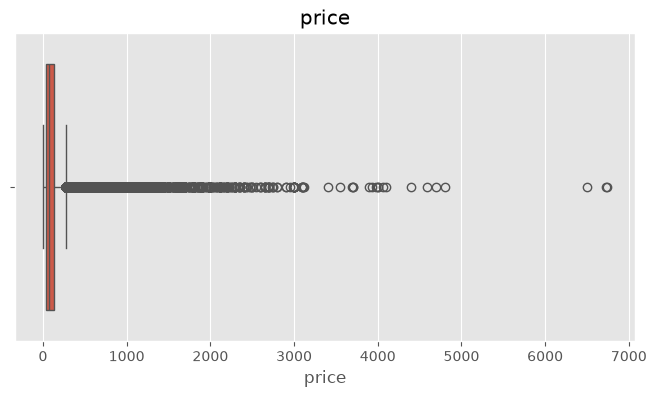

In [85]:
# Step 7 – Outlier Detection

# Price

plot_boxplot(
    order_items,
    "price"
)

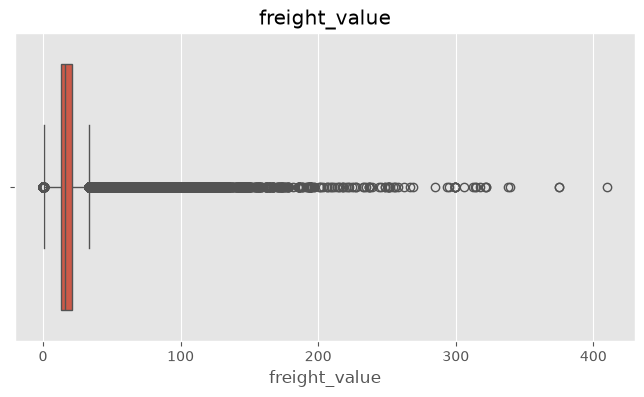

In [86]:
# Freight

plot_boxplot(
    order_items,
    "freight_value"
)

In [87]:
# Count outliers.

price_outliers = detect_outliers_iqr(
    order_items,
    "price"
)

print(
    "Price Outliers:",
    len(price_outliers)
)
freight_outliers = detect_outliers_iqr(
    order_items,
    "freight_value"
)

print(
    "Freight Outliers:",
    len(freight_outliers)
)

Price Outliers: 8427
Freight Outliers: 12134


In [88]:
# Step 8 – Validate Item Sequence

# Within each order, item numbers should be sequential (1, 2, 3, ...).

order_items.groupby("order_id")["order_item_id"].max().head()

order_id
00010242fe8c5a6d1ba2dd792cb16214    1
00018f77f2f0320c557190d7a144bdd3    1
000229ec398224ef6ca0657da4fc703e    1
00024acbcdf0a6daa1e931b038114c75    1
00042b26cf59d7ce69dfabb4e55b4fd9    1
Name: order_item_id, dtype: int64

In [89]:
# Step 9 – Final Validation

order_items_validation = {
    "Rows": len(order_items),
    "Columns": order_items.shape[1],
    "Missing Values": order_items.isnull().sum().sum(),
    "Duplicate Rows": order_items.duplicated().sum(),
    "Unique Orders": order_items["order_id"].nunique(),
    "Unique Products": order_items["product_id"].nunique(),
    "Unique Sellers": order_items["seller_id"].nunique()
}

pd.DataFrame(
    order_items_validation.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows,112650
1,Columns,7
2,Missing Values,0
3,Duplicate Rows,0
4,Unique Orders,98666
5,Unique Products,32951
6,Unique Sellers,3095


In [90]:
# Step 10 – Export

order_items.to_csv(
    "../dataset/cleaned/order_items_cleaned.csv",
    index=False
)

Section 11 – Clean Payments Dataset

In [91]:
# Step 1 – Dataset Summary

dataset_summary(
    payments,
    "Payments Dataset"
)

PAYMENTS DATASET
Rows    : 103886
Columns : 5

First Five Rows


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [92]:
# Step 2 – Missing Value Analysis

missing_summary(payments)

,Missing Count,Missing Percentage


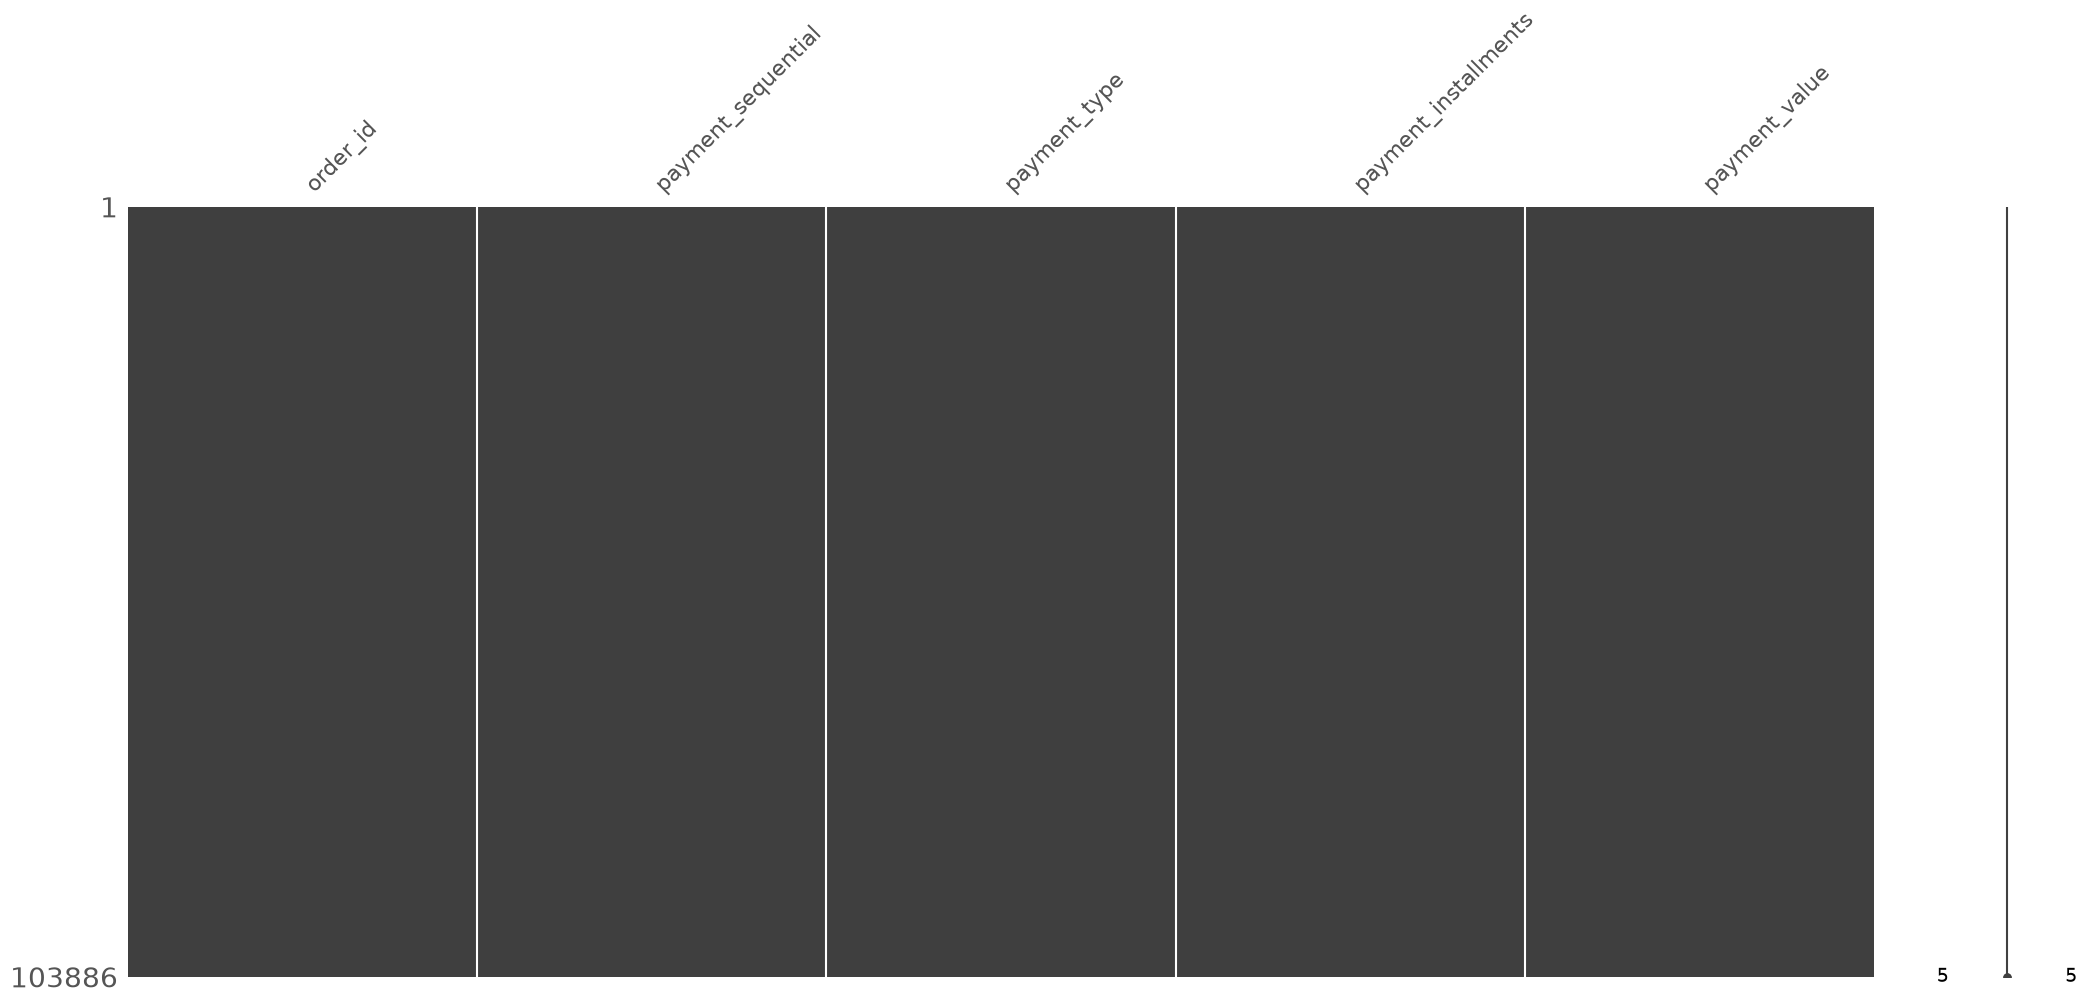

In [93]:
# Visualize 

msno.matrix(payments)

plt.show()

In [94]:
# Step 3 – Duplicate Record Analysis

duplicate_summary(payments)

""" If duplicates exist:

payments_before = payments.copy()

payments = remove_duplicates(payments)

compare_shape(
    payments_before,
    payments
)"""

Duplicate Rows : 0


' If duplicates exist:\n\npayments_before = payments.copy()\n\npayments = remove_duplicates(payments)\n\ncompare_shape(\n    payments_before,\n    payments\n)'

In [95]:
# Step 4 – Validate Foreign Key (order_id)

# Ensure every payment belongs to an existing order.

invalid_payments = validate_foreign_key(
    payments,
    "order_id",
    orders,
    "order_id"
)

Foreign Key: order_id
Invalid Records: 0


In [96]:
# Step 5 – Validate Payment Methods

payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [97]:
# Check for the unexpected Values 

expected_payment_types = {
    "credit_card",
    "boleto",
    "voucher",
    "debit_card",
    "not_defined"
}

invalid_payment_types = payments[
    ~payments["payment_type"].isin(expected_payment_types)
]

invalid_payment_types

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [98]:
# Step 6 – Validate Numeric Columns Payment Value

# Payment value should always be greater than zero.

payments[
    payments["payment_value"] <= 0
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [99]:
# Installments

# Installments should be at least 1.

payments[
    payments["payment_installments"] <= 0
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [100]:
# Payment Sequence

# Sequence number should also be greater than zero.

payments[
    payments["payment_sequential"] <= 0
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [101]:
#nStep 7 – Analyze Multiple Payments

# One order may have multiple payment records.


multiple_payments = payments.groupby("order_id").size()

multiple_payments = multiple_payments[
    multiple_payments > 1
]

multiple_payments.head()

order_id
0016dfedd97fc2950e388d2971d718c7    2
002f19a65a2ddd70a090297872e6d64e    2
0071ee2429bc1efdc43aa3e073a5290e    2
009ac365164f8e06f59d18a08045f6c4    6
00b4a910f64f24dbcac04fe54088a443    2
dtype: int64

In [102]:
# Count how many orders have multiple payments.

len(multiple_payments)

2961

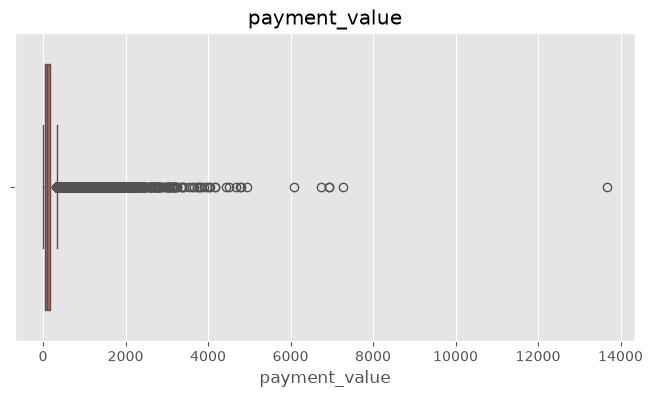

In [103]:
# Step 8 – Outlier Detection for Payment Value

# Visualize.

plot_boxplot(
    payments,
    "payment_value"
)



In [104]:
# Count outliers

payment_outliers = detect_outliers_iqr(
    payments,
    "payment_value"
)

print(
    "Payment Value Outliers:",
    len(payment_outliers)
)

Payment Value Outliers: 7981


In [105]:
# Final validation

payments_validation = {
    "Rows": len(payments),
    "Columns": payments.shape[1],
    "Missing Values": payments.isnull().sum().sum(),
    "Duplicate Rows": payments.duplicated().sum(),
    "Unique Orders": payments["order_id"].nunique(),
    "Payment Methods": payments["payment_type"].nunique()
}

pd.DataFrame(
    payments_validation.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows,103886
1,Columns,5
2,Missing Values,0
3,Duplicate Rows,0
4,Unique Orders,99440
5,Payment Methods,5


In [106]:
# Step 10 – Export

payments.to_csv(
    "../dataset/cleaned/payments_cleaned.csv",
    index=False
)

Section 12 – Clean Reviews Dataset

In [107]:
# Step 1 – Dataset Summary

dataset_summary(
    reviews,
    "Reviews Dataset"
)

REVIEWS DATASET
Rows    : 99224
Columns : 7

First Five Rows


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [108]:
# Step 2 – Missing Value Analysis
missing_summary(reviews)

,Missing Count,Missing Percentage
review_comment_title,87656,88.34
review_comment_message,58247,58.70


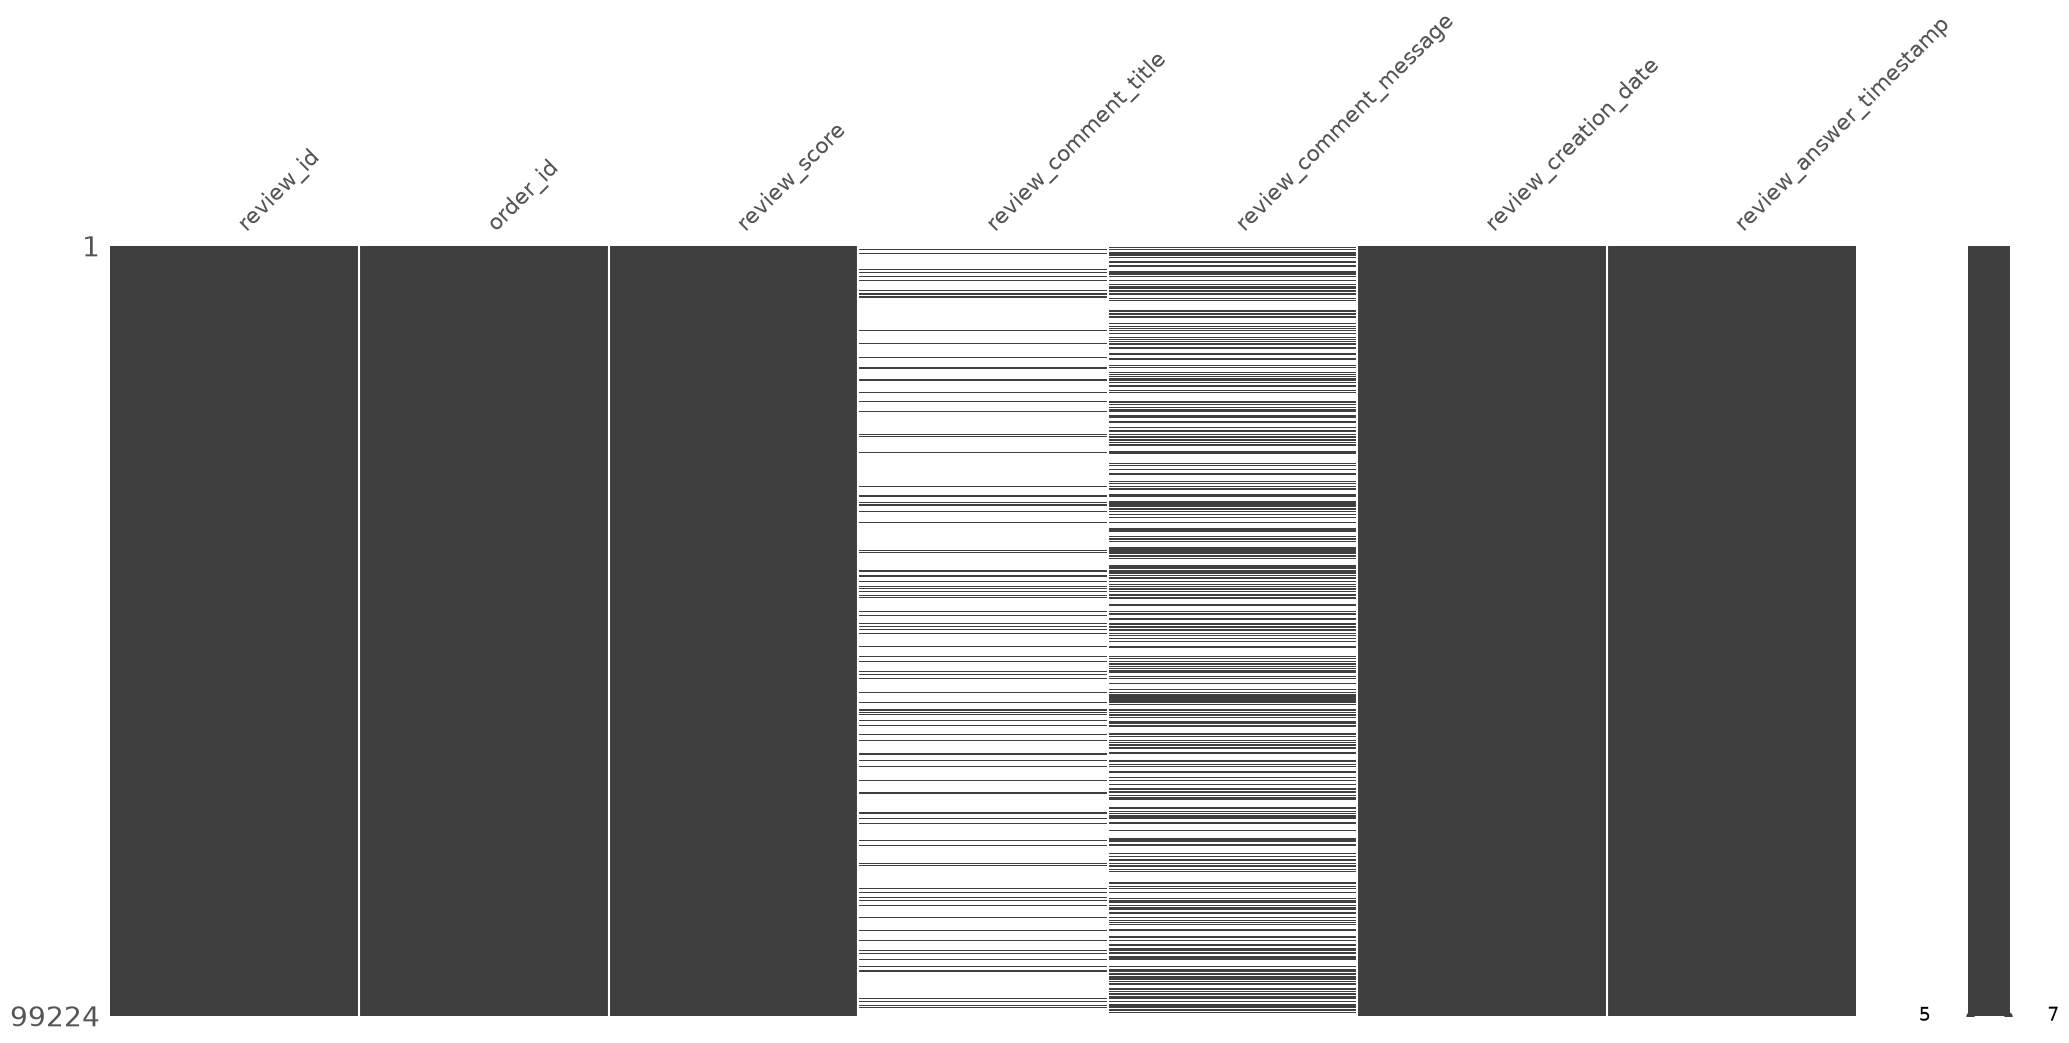

In [109]:
# Visualize:

msno.matrix(reviews)

plt.show()

In [110]:
# Step 3 – Duplicate Record Analysis

duplicate_summary(reviews)

""" If duplicate rows exist:

reviews_before = reviews.copy()

reviews = remove_duplicates(reviews)

compare_shape(
    reviews_before,
    reviews
)"""

Duplicate Rows : 0


' If duplicate rows exist:\n\nreviews_before = reviews.copy()\n\nreviews = remove_duplicates(reviews)\n\ncompare_shape(\n    reviews_before,\n    reviews\n)'

In [111]:
# Step 4 – Validate Foreign Key (order_id)

# Every review should belong to a valid order.

invalid_reviews = validate_foreign_key(
    reviews,
    "order_id",
    orders,
    "order_id"
)

Foreign Key: order_id
Invalid Records: 0


In [112]:
# Step 5 – Validate Review Score

# Review scores should only be between 1 and 5.

reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [113]:
# Check for invalid scores.

invalid_scores = reviews[
    ~reviews["review_score"].between(1, 5)
]

invalid_scores

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


In [114]:
# Step 6 – Convert Date Columns

date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for column in date_columns:
    reviews[column] = pd.to_datetime(
        reviews[column],
        errors="coerce"
    )

In [115]:
# Verify:

reviews[date_columns].dtypes

review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

In [116]:
# Step 7 – Handle Missing Text Fields

reviews["has_review_title"] = (
    reviews["review_comment_title"]
    .notna()
)

reviews["has_review_message"] = (
    reviews["review_comment_message"]
    .notna()
)

In [117]:
# Step 8 – Validate Date Logic

# The review should not be created after the answer timestamp.

reviews[
    reviews["review_creation_date"] >
    reviews["review_answer_timestamp"]
]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,has_review_title,has_review_message


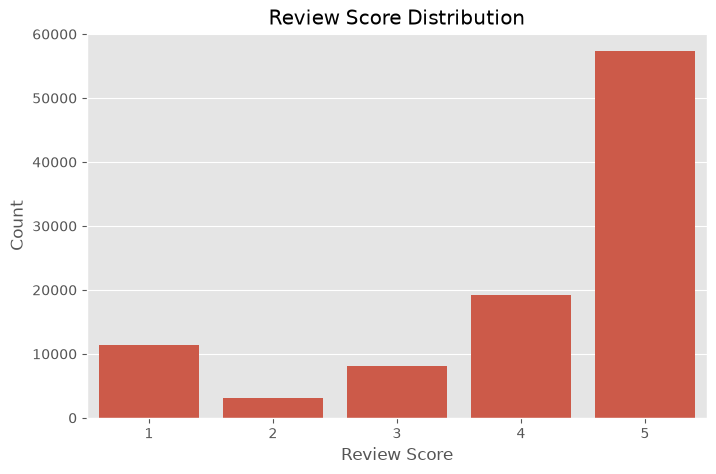

In [118]:
# Step 9 – Review Score Distribution

# Visualize the ratings.

plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews,
    x="review_score"
)

plt.title("Review Score Distribution")

plt.xlabel("Review Score")

plt.ylabel("Count")

plt.show()

In [119]:
# Step 10 – Final Validation

reviews_validation = {
    "Rows": len(reviews),
    "Columns": reviews.shape[1],
    "Missing Values": reviews.isnull().sum().sum(),
    "Duplicate Rows": reviews.duplicated().sum(),
    "Unique Reviews": reviews["review_id"].nunique(),
    "Unique Orders": reviews["order_id"].nunique()
}

pd.DataFrame(
    reviews_validation.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows,99224
1,Columns,9
2,Missing Values,145903
3,Duplicate Rows,0
4,Unique Reviews,98410
5,Unique Orders,98673


In [120]:
#Step 11 – Export

reviews.to_csv(
    "../dataset/cleaned/reviews_cleaned.csv",
    index=False
)

Section 13 – Clean Geolocation Dataset

In [121]:
# Step 1 – Dataset Summary

dataset_summary(
    geolocation,
    "Geolocation Dataset"
)

GEOLOCATION DATASET
Rows    : 1000163
Columns : 5

First Five Rows


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [122]:
# Step 2 – Missing Value Analysis

missing_summary(geolocation)

,Missing Count,Missing Percentage


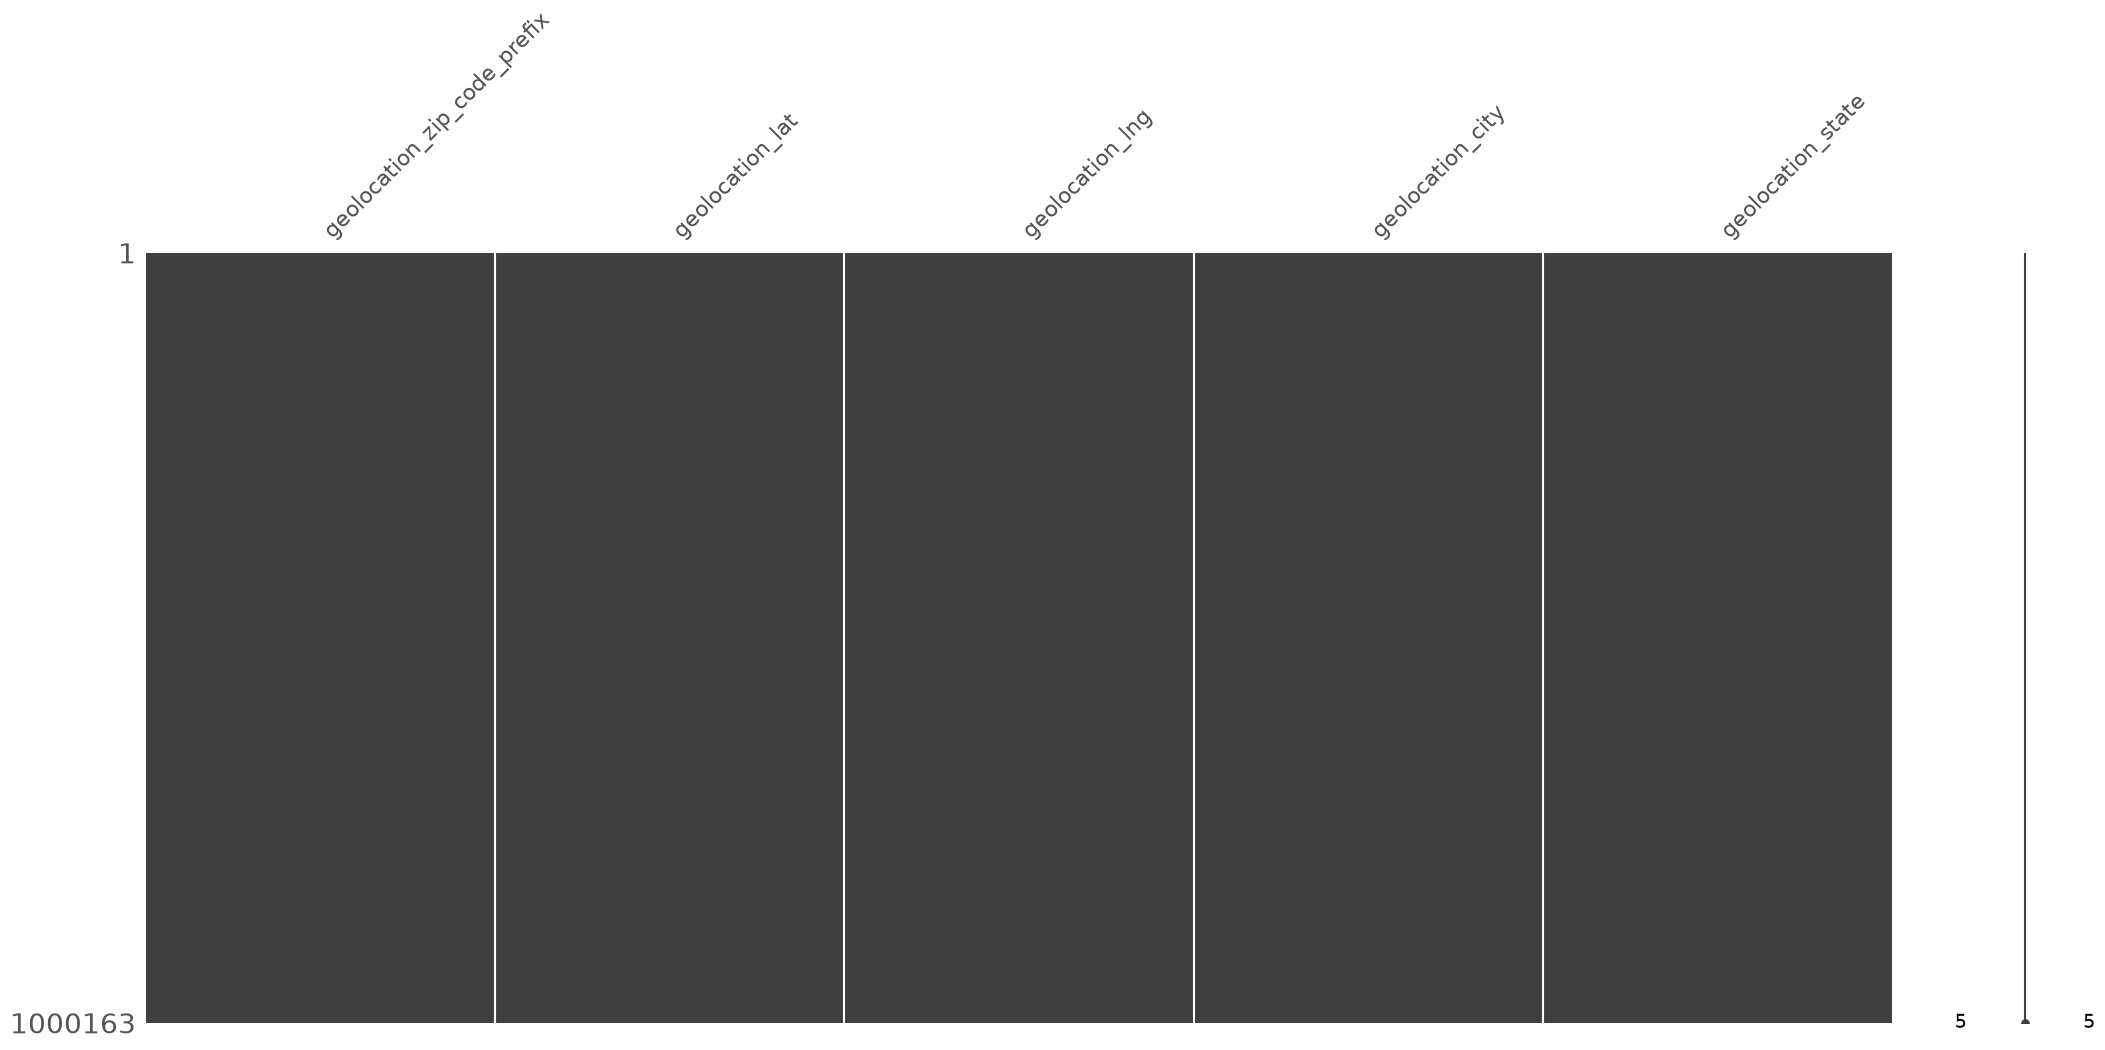

In [123]:
# Visualize:

msno.matrix(geolocation)

plt.show()

In [124]:
# Step 3 – Duplicate Record Analysis

# Check complete duplicate rows.

duplicate_summary(geolocation)

"""If duplicate rows exist:

geolocation_before = geolocation.copy()

geolocation = remove_duplicates(geolocation)

compare_shape(
    geolocation_before,
    geolocation
)"""

Duplicate Rows : 261831


'If duplicate rows exist:\n\ngeolocation_before = geolocation.copy()\n\ngeolocation = remove_duplicates(geolocation)\n\ncompare_shape(\n    geolocation_before,\n    geolocation\n)'

In [125]:
# Step 4 – Validate Coordinates

# Latitude should be between -90 and 90.

invalid_latitude = geolocation[
    ~geolocation["geolocation_lat"].between(-90, 90)
]

invalid_latitude

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


In [136]:
# Longitude should be between -180 and 180.

invalid_longitude = geolocation[
    ~geolocation["geolocation_lng"].between(-180, 180)
]

invalid_longitude

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


In [127]:
# Step 5 – Validate ZIP Prefix

# ZIP prefixes should be positive.

geolocation[
    geolocation["geolocation_zip_code_prefix"] <= 0
]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


In [128]:
# Step 6 – Validate State Codes

# State abbreviations should contain exactly two uppercase letters.

invalid_states = geolocation[
    geolocation["geolocation_state"].str.len() != 2
]

invalid_states

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


In [129]:
# Step 7 – Standardize Text Columns

# Normalize city and state names.

geolocation["geolocation_city"] = (
    geolocation["geolocation_city"]
    .str.strip()
    .str.title()
)

geolocation["geolocation_state"] = (
    geolocation["geolocation_state"]
    .str.strip()
    .str.upper()
)

In [130]:
# Step 8 – Analyze Duplicate ZIP Prefixes

# Count how many records share the same ZIP prefix.

zip_prefix_counts = (
    geolocation["geolocation_zip_code_prefix"]
    .value_counts()
)

zip_prefix_counts.head(10)

geolocation_zip_code_prefix
24220    1146
24230    1102
38400     965
35500     907
11680     879
22631     832
30140     810
11740     788
38408     773
28970     743
Name: count, dtype: int64

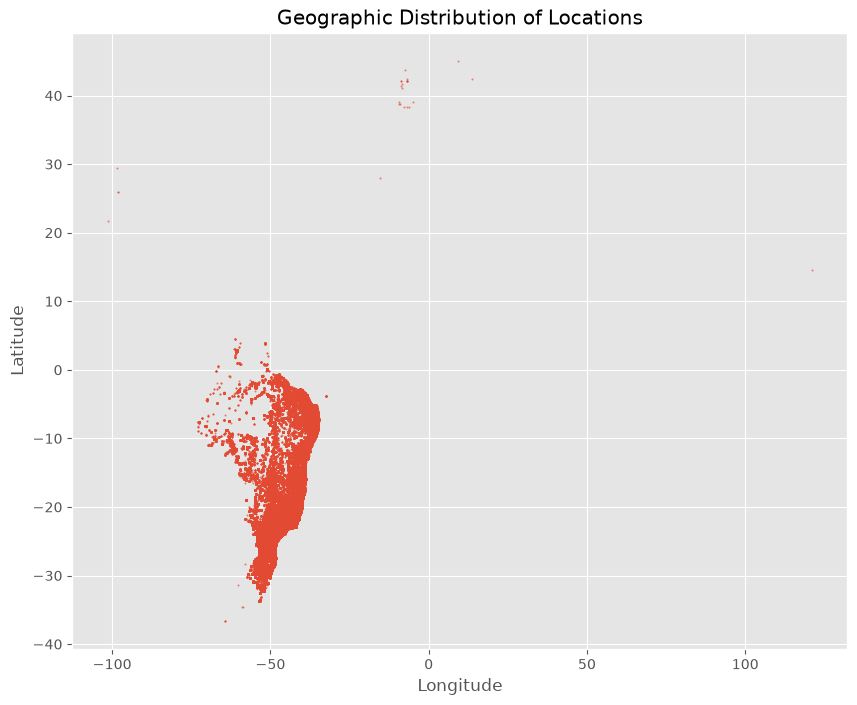

In [131]:
# Step 9 – Visualize Coordinate Distribution

# Plot the geographic spread of the data.

plt.figure(figsize=(10, 8))

plt.scatter(
    geolocation["geolocation_lng"],
    geolocation["geolocation_lat"],
    s=1,
    alpha=0.5
)

plt.title("Geographic Distribution of Locations")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.show()

In [132]:
# Step 10 – Final Validation

geolocation_validation = {
    "Rows": len(geolocation),
    "Columns": geolocation.shape[1],
    "Missing Values": geolocation.isnull().sum().sum(),
    "Duplicate Rows": geolocation.duplicated().sum(),
    "Unique ZIP Prefixes": geolocation["geolocation_zip_code_prefix"].nunique(),
    "Unique Cities": geolocation["geolocation_city"].nunique(),
    "Unique States": geolocation["geolocation_state"].nunique()
}

pd.DataFrame(
    geolocation_validation.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows,1000163
1,Columns,5
2,Missing Values,0
3,Duplicate Rows,261831
4,Unique ZIP Prefixes,19015
5,Unique Cities,8010
6,Unique States,27


In [133]:
# Step 11 – Export

geolocation.to_csv(
    "../dataset/cleaned/geolocation_cleaned.csv",
    index=False
)

In [134]:
# Phase 2 Completed

# Final Validation Summary

cleaning_summary = pd.DataFrame({
    "Dataset": [
        "Translation",
        "Products",
        "Customers",
        "Sellers",
        "Orders",
        "Order Items",
        "Payments",
        "Reviews",
        "Geolocation"
    ],
    "Rows": [
        len(translation),
        len(products),
        len(customers),
        len(sellers),
        len(orders),
        len(order_items),
        len(payments),
        len(reviews),
        len(geolocation)
    ],
    "Columns": [
        translation.shape[1],
        products.shape[1],
        customers.shape[1],
        sellers.shape[1],
        orders.shape[1],
        order_items.shape[1],
        payments.shape[1],
        reviews.shape[1],
        geolocation.shape[1]
    ],
    "Missing Values": [
        translation.isnull().sum().sum(),
        products.isnull().sum().sum(),
        customers.isnull().sum().sum(),
        sellers.isnull().sum().sum(),
        orders.isnull().sum().sum(),
        order_items.isnull().sum().sum(),
        payments.isnull().sum().sum(),
        reviews.isnull().sum().sum(),
        geolocation.isnull().sum().sum()
    ]
})

cleaning_summary

,Dataset,Rows,Columns,Missing Values
0,Translation,71,2,0
1,Products,32951,9,1838
2,Customers,99441,5,0
3,Sellers,3095,4,0
4,Orders,99441,8,4908
5,Order Items,112650,7,0
6,Payments,103886,5,0
7,Reviews,99224,9,145903
8,Geolocation,1000163,5,0
